# Goal
Load and downsample the data

4x: 1.8x1.8x2.0 um/pixel (xyz)
9x: 0.71x0.71x2.0 um/pixel (xyz) 
But there are some with z=0.71, isotropic.


In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
from glob import glob
from os.path import join
import tifffile

import numpy as np

In [2]:
rootdir = '/media/dtward/YangLab_5TB_WDBlue/20241017_5xFAD_Etv1_MORF3_MEF119_3_4m_RH/4x/RES(7668x5824x3072)/464720/464720_499580'
rootdir = '/media/dtward/YangLab_5TB_WDBlue/20241017_5xFAD_Etv1_MORF3_MEF119_3_4m_RH/9x/RES(15290x11566x3184)/459340/459340_505140'
channel = 'C1'
res = '4x'
res = '9x'
name = '20241017_5xFAD_Etv1_MORF3_MEF119_3_4m_RH'
files = glob(join(rootdir,'*' + channel + '*.tif'))
files.sort()

In [3]:
files

['/media/dtward/YangLab_5TB_WDBlue/20241017_5xFAD_Etv1_MORF3_MEF119_3_4m_RH/9x/RES(15290x11566x3184)/459340/459340_505140/459340_505140_000080_C1.tif',
 '/media/dtward/YangLab_5TB_WDBlue/20241017_5xFAD_Etv1_MORF3_MEF119_3_4m_RH/9x/RES(15290x11566x3184)/459340/459340_505140/459340_505140_000100_C1.tif',
 '/media/dtward/YangLab_5TB_WDBlue/20241017_5xFAD_Etv1_MORF3_MEF119_3_4m_RH/9x/RES(15290x11566x3184)/459340/459340_505140/459340_505140_000120_C1.tif',
 '/media/dtward/YangLab_5TB_WDBlue/20241017_5xFAD_Etv1_MORF3_MEF119_3_4m_RH/9x/RES(15290x11566x3184)/459340/459340_505140/459340_505140_000140_C1.tif',
 '/media/dtward/YangLab_5TB_WDBlue/20241017_5xFAD_Etv1_MORF3_MEF119_3_4m_RH/9x/RES(15290x11566x3184)/459340/459340_505140/459340_505140_000160_C1.tif',
 '/media/dtward/YangLab_5TB_WDBlue/20241017_5xFAD_Etv1_MORF3_MEF119_3_4m_RH/9x/RES(15290x11566x3184)/459340/459340_505140/459340_505140_000180_C1.tif',
 '/media/dtward/YangLab_5TB_WDBlue/20241017_5xFAD_Etv1_MORF3_MEF119_3_4m_RH/9x/RES(15290

In [4]:
files[0]

'/media/dtward/YangLab_5TB_WDBlue/20241017_5xFAD_Etv1_MORF3_MEF119_3_4m_RH/9x/RES(15290x11566x3184)/459340/459340_505140/459340_505140_000080_C1.tif'

In [5]:
file = files[0]
with tifffile.TiffFile(file) as tif:
    for page in tif.pages:
        for tag in page.tags:
            tag_name, tag_value = tag.name, tag.value
            print('*'*10 + tag_name + '*'*10)
            print(tag_value)


**********NewSubfileType**********
FILETYPE.PAGE
**********ImageWidth**********
11566
**********ImageLength**********
15290
**********BitsPerSample**********
16
**********Compression**********
COMPRESSION.LZW
**********PhotometricInterpretation**********
PHOTOMETRIC.MINISBLACK
**********StripOffsets**********
(8, 2082, 4124, 6147, 8186, 11665, 15155, 18630, 22075, 26900, 31695, 36496, 41314, 46106, 50916, 55701, 60507, 65346, 70120, 74896, 79691, 84476, 89286, 94092, 98905, 103721, 108501, 113277, 118117, 122911, 127688, 132470, 137273, 142044, 146824, 151616, 156389, 161159, 165948, 170712, 175482, 180286, 185050, 189817, 194591, 199392, 204193, 208943, 213749, 218579, 223361, 228159, 232968, 237780, 242556, 247342, 252130, 256934, 261681, 266451, 271240, 276025, 280787, 285545, 290336, 295082, 299864, 304649, 309447, 314200, 318959, 323732, 328500, 333259, 337942, 342703, 347473, 352255, 356977, 361717, 366466, 371245, 375991, 380764, 385522, 390274, 395041, 399793, 404585, 409314, 4

In [6]:
I = tifffile.imread(files[len(files)//2])

In [7]:
I.shape

(15290, 11566)

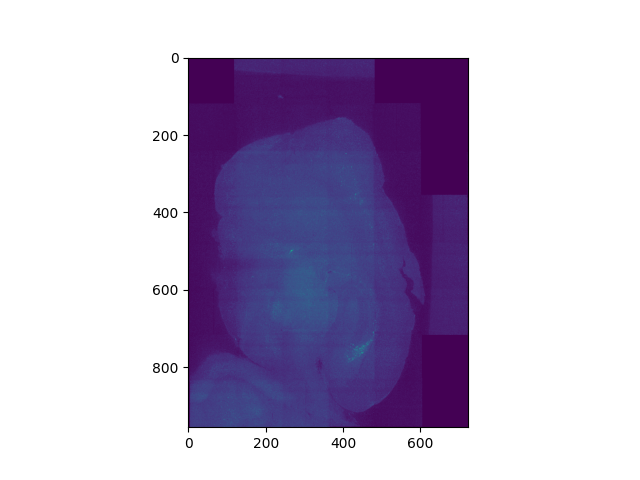

In [8]:
downshow = 8
if res == '9x':
    downshow = 16
fig,ax = plt.subplots()
ax.imshow(I[::downshow,::downshow])

In [9]:
nI0 = np.array([len(files), I.shape[0], I.shape[1]])
dI0 = np.array([2.0, 1.8, 1.8]) # for 4x
if res == '9x':
    dI0 = np.array([2.0,0.71,0.71])    
xI0 = [(np.arange(n) - (n-1)/2)*d for n,d in zip(nI0,dI0)]


In [10]:
# let's downsample to 25 um
dIdes = 25.0
down = dIdes/dI0

down

array([12.5       , 35.21126761, 35.21126761])

In [11]:
# do I want to do exactly 25?
# what would that mean
# I would have weights
# it will be slower

# first do the last dim
def downsample2d(I,down):
    Id = []
    start = 1e-6 # this will be a float
    end = False
    while True:
        stop = start + down[-1]

        # now a weight for the first pixel
        start0 = np.floor(start).astype(int)
        startf = 1.0 - (start - start0) # if this is small, we want a big weight


        # a weight for the last pixel
        stop1 = np.ceil(stop).astype(int)
        if stop1 >= I.shape[-1]:
            stop1 = I.shape[-1]-1
            stop = stop1-1 # hack to make the weight 1
            end = True
        stopf = stop1 - stop
        w = np.ones(stop1-start0+1)

        w[0] = startf
        w[-1] = stopf


        Id_ = np.sum(I[...,start0:stop1+1]*w,-1)/np.sum(w)
        Id.append(Id_)

        start = start + down[-1]

        if end:
            break
    Id = np.stack(Id,-1)


    # now second last
    Idd = []
    start = 1e-6 # this will be a float
    end = False
    while True:
        stop = start + down[-2]

        # now a weight for the first pixel
        start0 = np.floor(start).astype(int)
        startf = 1.0 - (start - start0) # if this is small, we want a big weight


        # a weight for the last pixel
        stop1 = np.ceil(stop).astype(int)
        if stop1 >= I.shape[-2]:
            stop1 = I.shape[-2]-1
            stop = stop1-1 # hack to make the weight 1
            end = True
        stopf = stop1 - stop
        w = np.ones(stop1-start0+1)

        w[0] = startf
        w[-1] = stopf




        Id_ = np.sum(Id[...,start0:stop1+1,:]*w[...,None],-2)/np.sum(w)
        Idd.append(Id_)

        start = start + down[-2]

        if end:
            break
    Idd = np.stack(Idd,-2)
    return Idd



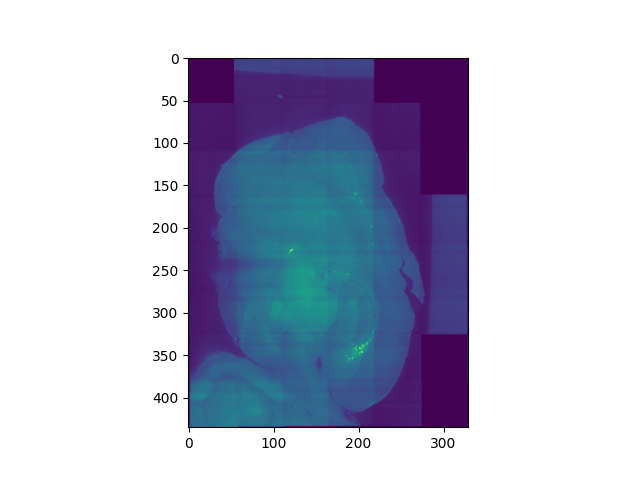

In [12]:
Id = downsample2d(I,down)
fig,ax = plt.subplots()
ax.imshow(Id)

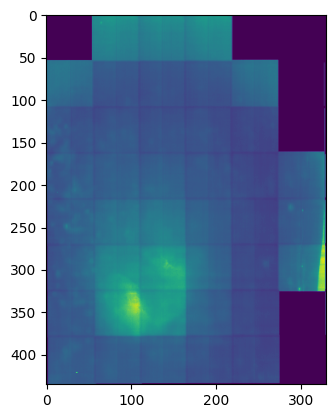

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



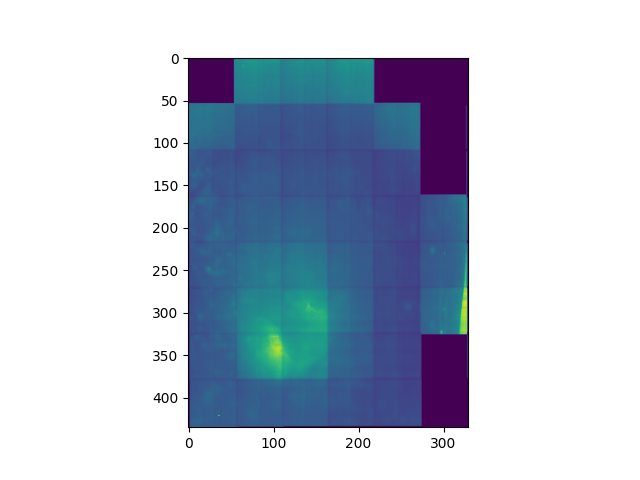

In [13]:
fig,ax = plt.subplots()
hfig = display(fig,display_id=True)
Idd = []
for i in range(len(files)):
    I = tifffile.imread(files[i])
    Id = downsample2d(I,down)
    Idd.append(Id)
    ax.cla()
    ax.imshow(Id)
    fig.canvas.draw()
    hfig.update(fig)
    

In [14]:
Idd = np.stack(Idd)

In [15]:
Idd.shape

(3184, 435, 329)

In [16]:
down[-3]

12.5

In [17]:
# do the last axis

Iddd = []
start = 1e-6 # this will be a float
end = False
while True:
    stop = start + down[-3]

    # now a weight for the first pixel
    start0 = np.floor(start).astype(int)
    startf = 1.0 - (start - start0) # if this is small, we want a big weight


    # a weight for the last pixel
    stop1 = np.ceil(stop).astype(int)
    if stop1 >= Idd.shape[-3]:
        stop1 = Idd.shape[-3]-1
        stop = stop1-1 # hack to make the weight 1
        end = True
    stopf = stop1 - stop
    w = np.ones(stop1-start0+1)

    w[0] = startf
    w[-1] = stopf


    Id_ = np.sum(Idd[...,start0:stop1+1,:,:]*w[...,None,None],-3)/np.sum(w)
    
    Iddd.append(Id_)

    start = start + down[-3]

    if end:
        break
Iddd = np.stack(Iddd,-3)

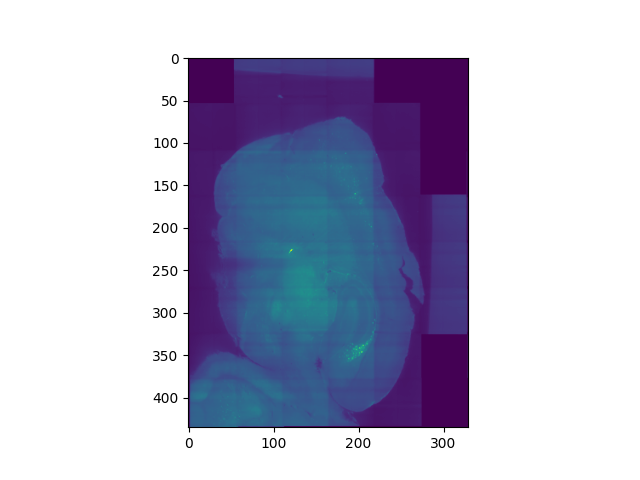

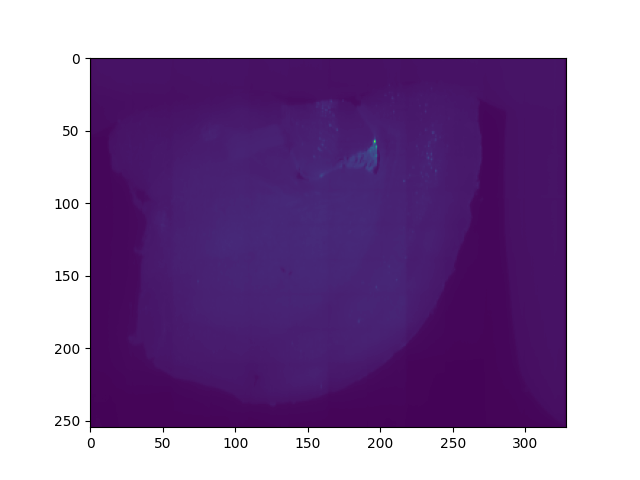

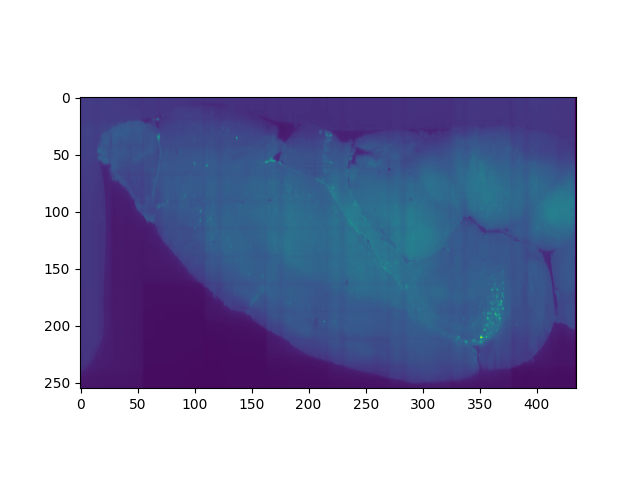

In [18]:
fig,ax = plt.subplots()
ax.imshow(Iddd[Iddd.shape[0]//2])
fig,ax = plt.subplots()
ax.imshow(Iddd[:,Iddd.shape[1]//2])
fig,ax = plt.subplots()
ax.imshow(Iddd[:,:,Iddd.shape[2]//2])

In [19]:
Iddd.shape

(255, 435, 329)

In [20]:
# now the locations
xI = [np.arange(n)*dIdes + x[0] for x,n in zip(xI0,Iddd.shape)]

In [21]:
# write it out


In [22]:
savename = '_'.join([name,res,channel]) + '.npz'
np.savez(savename,xI=np.array(xI,dtype=object),I=Iddd[None])

In [23]:
I.shape

(15290, 11566)

In [24]:
Iddd.shape

(255, 435, 329)

In [25]:
# quick statement about bias
# \sum_i |I_i exp(b_i) - J_i|^2
#goal is to optimize this loss
# we can also take the log
# f(b) = log( \sum_i |I_i exp(b_i) - J_i|^2 )
# we want to transform sum of log into log of sum
# this is a typical thing the EM algorithm does
# f(b^{k}) = log( \sum_i |I_i exp(b^{k}_i) - J_i|^2 )
# so what am I doing here?
# I want to solve this problem with the exp
# but do it in terms a a simple quadratic fit
# iterating

In [28]:
1

1